<a href="https://colab.research.google.com/github/ANJALICHAMOLI/PyTorch/blob/main/11_pytorch_gpu_optimized_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from torchvision import datasets,transforms

torch.manual_seed(42)
transform = transforms.ToTensor() #changes an image into a Pytorch tensor

train_ds = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.0MB/s]


In [ ]:
images = train_ds.data
labels = train_ds.targets

In [ ]:
images=images.view(60000,-1)

In [ ]:
print(images.shape)
print(labels.shape)

torch.Size([60000, 784])
torch.Size([60000])


In [ ]:
pix_col = [f'pixel{i}' for i in range(1,785)]
df = pd.DataFrame(images, columns=pix_col)
df["label"] = labels

In [ ]:
df.shape

(60000, 785)

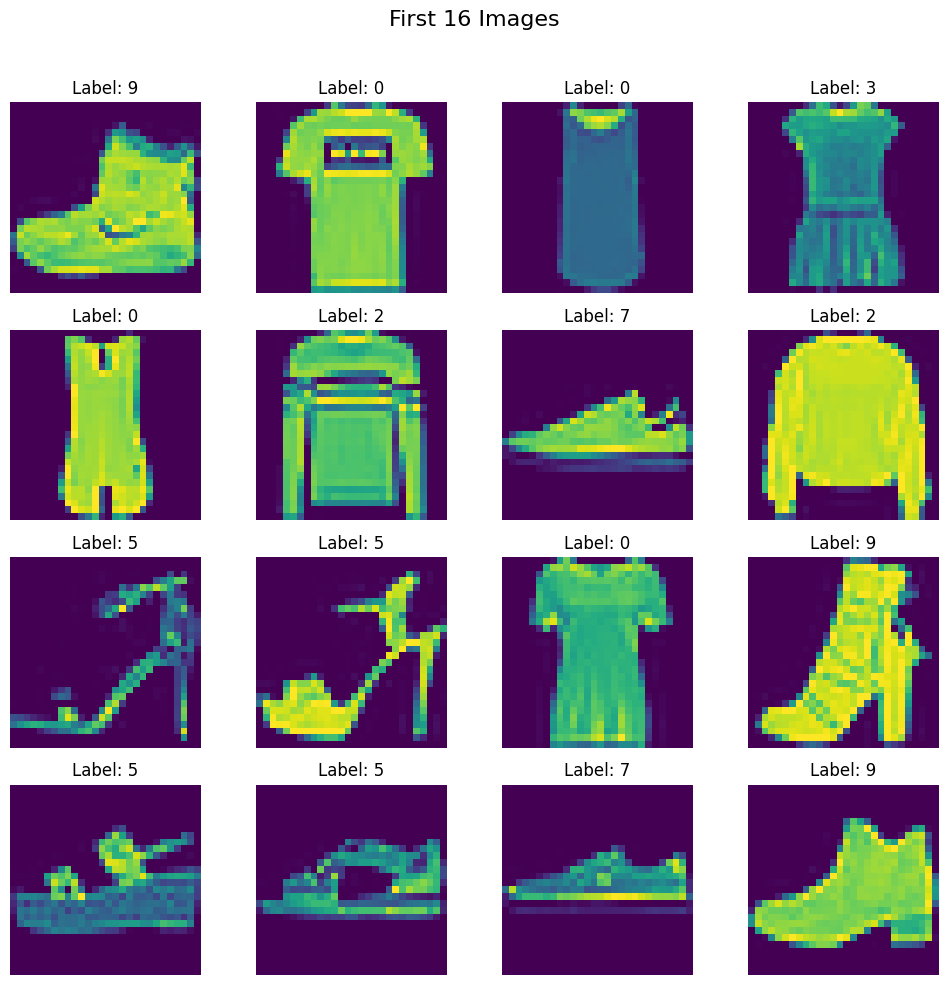

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i , :-1].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, -1]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [ ]:
# train test split

X = df.iloc[:, :-1].values
y = df.iloc[:,-1].values

In [ ]:
y

array([9, 0, 0, ..., 3, 0, 5])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)

In [ ]:
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
class NN(nn.Module):

  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, x):

    return self.model(x)

In [ ]:
# objective function
def objective(trial):

  # next hyperparameter values from the search space
  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  neurons_per_layer = trial.suggest_int("neurons_per_layer", 8, 128, step=8)
  epochs = trial.suggest_int("epochs", 10, 50, step=10)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
  optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # model init
  input_dim = 784
  output_dim = 10

  model = NN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  # optimizer selection
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

  if optimizer_name == 'Adam':
    optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop

  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()


  # evaluation
  model.eval()
  # evaluation on test data
  total = 0
  correct = 0

  with torch.no_grad():

    for batch_features, batch_labels in test_loader:

      # move data to gpu
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)

      _, predicted = torch.max(outputs, 1)

      total = total + batch_labels.shape[0]

      correct = correct + (predicted == batch_labels).sum().item()

    accuracy = correct/total

  return accuracy

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 30.1 MB/s eta 0:00:00


In [ ]:
import optuna

study = optuna.create_study(direction='maximize')

[I 2026-07-04 08:30:29,741] A new study created in memory with name: no-name-468f6426-3ed3-4723-8688-a822cc6b4788


In [ ]:
study.optimize(objective, n_trials=10)

[I 2026-07-04 08:35:12,795] Trial 0 finished with value: 0.8806666666666667 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 40, 'epochs': 40, 'learning_rate': 0.002864648501737611, 'dropout_rate': 0.1, 'batch_size': 16, 'optimizer': 'SGD', 'weight_decay': 0.00039010197942003814}. Best is trial 0 with value: 0.8806666666666667.
[I 2026-07-04 08:37:47,446] Trial 1 finished with value: 0.8915 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 88, 'epochs': 50, 'learning_rate': 0.00025051351082179746, 'dropout_rate': 0.2, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.00025985180005013423}. Best is trial 1 with value: 0.8915.
[I 2026-07-04 08:39:48,410] Trial 2 finished with value: 0.8725833333333334 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 56, 'epochs': 50, 'learning_rate': 0.0031775105806821176, 'dropout_rate': 0.5, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0006654416939383609}. Best is trial 1 with value: 0.8915.
[I 2

In [ ]:
study.best_value

0.8915

In [ ]:
study.best_params

{'num_hidden_layers': 2,
 'neurons_per_layer': 88,
 'epochs': 50,
 'learning_rate': 0.00025051351082179746,
 'dropout_rate': 0.2,
 'batch_size': 32,
 'optimizer': 'SGD',
 'weight_decay': 0.00025985180005013423}